# 2. Отбор признаков

**Методы**: Mutual Information, корреляционный анализ, экспертная оценка  
**Цель**: Обосновать выбор 7 финальных признаков для интерпретируемых моделей

In [ ]:
import sys, pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from sklearn.feature_selection import mutual_info_classif
from pathlib import Path
sys.path.append(str(Path().resolve().parent / 'src'))
from config import SELECTED_FEATURES, FEATURE_LABELS, TARGET_COL
from preprocessing import load_data

df = load_data()
X = df[SELECTED_FEATURES]
y = df[TARGET_COL]

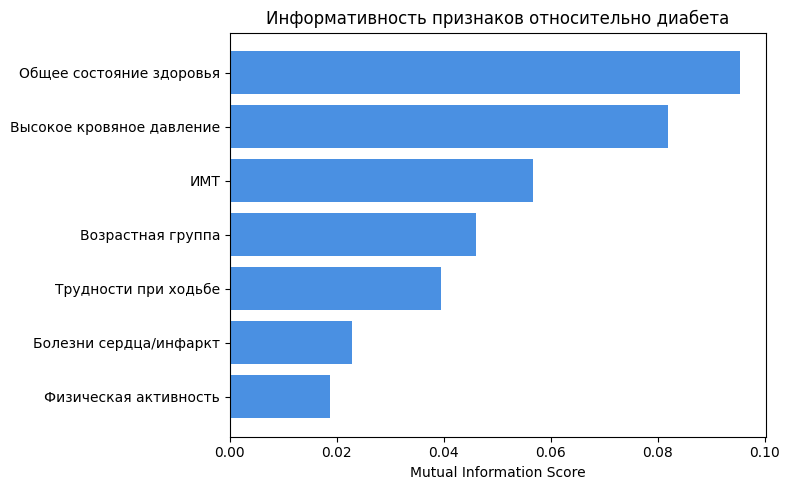

             feature                     label  mi_score
             GenHlth  Общее состояние здоровья  0.095444
              HighBP Высокое кровяное давление  0.081973
                 BMI                       ИМТ  0.056717
                 Age         Возрастная группа  0.045994
            DiffWalk      Трудности при ходьбе  0.039514
HeartDiseaseorAttack    Болезни сердца/инфаркт  0.022877
        PhysActivity     Физическая активность  0.018780


In [ ]:
mi_scores = mutual_info_classif(X, y, random_state=42)
mi_df = pd.DataFrame({
    'feature': SELECTED_FEATURES,
    'label': [FEATURE_LABELS[f] for f in SELECTED_FEATURES],
    'mi_score': mi_scores
}).sort_values('mi_score', ascending=False).reset_index(drop=True)

plt.figure(figsize=(8, 5))
plt.barh(mi_df['label'][::-1], mi_df['mi_score'][::-1], color='#4A90E2')
plt.xlabel('Mutual Information Score')
plt.title('Информативность признаков относительно диабета')
plt.tight_layout()
plt.savefig('figures/mi_scores.png', dpi=300)
plt.show()
print(mi_df.to_string(index=False))

In [ ]:
numeric = ['BMI']  # остальные — бинарные/ординальные
if len(numeric) > 1:
    plt.figure(figsize=(6, 5))
    sns.heatmap(df[numeric + [TARGET_COL]].corr(), annot=True, cmap='coolwarm', center=0)
    plt.title('Корреляционная матрица (числовые признаки)')
    plt.tight_layout()
    plt.savefig('figures/correlation.png', dpi=300)
    plt.show()

### Обоснование финального набора признаков:

| Признак | MI-скор | Клиническая значимость | Решение |
|---------|---------|------------------------|---------|
| GenHlth | 0.0954 | Высокая (самооценка здоровья — интегральный индикатор) | ✅ Включён |
| HighBP  | 0.0820 | Высокая (гипертония — коморбидный фактор) | ✅ Включён |
| BMI     | 0.0567 | Очень высокая (ожирение — ключевой модифицируемый фактор) | ✅ Включён |
| Age     | 0.0460 | Средняя (риск растёт с возрастом) | ✅ Включён |
| DiffWalk| 0.0395 | Средняя (маркер общего состояния) | ✅ Включён |
| HeartDiseaseorAttack | 0.0229 | Высокая, но низкий MI | ✅ Включён (экспертно) |
| PhysActivity | 0.0188 | Высокая, но слабый сигнал в данных | ✅ Включён (для полноты) |

**Итог**: 7 признаков обеспечивают баланс между статистической информативностью, интерпретируемостью и клинической релевантностью.